# 04 データ分析まとめ

**目的**:  
高圧下でのLa2Ni3水素化反応 放射光XRD (SPring-8 BL14B1)について本Notebookは01〜03の結果を統合し、文献(Sato et al. 2023/2025)との比較考察を行う。

## 対象読者・前提知識・動作環境・版とライセンス

**対象読者**:
ARIMデータポータル会員の研究者・技術者を想定しています。以下の基礎知識を前提としています:

- Pythonの基礎文法（変数・関数・for文・pandas/numpyの基本操作）
- **scikit-learnの機械学習基礎**: 主成分分析（PCA）、K-means クラスタリング、交差検証（cross-validation）、モデル評価指標（精度・RMSE等）
- **XRDの基本知識**: Braggの法則、d間隔と結晶構造の関係、高温・高圧下での時間分解測定の概念

一方、放射光X線回折(XRD)・高圧実験の詳細な専門知識は前提としません。専門用語は初出時に簡単な説明を添えます。

**シリーズ構成**:  
本ノートブックは「La2Ni3高圧水素化その場観察XRD」4部作の第4部（最終回）です（第1部: `01_eda.ipynb`、第2部: `02_signal_processing.ipynb`、第3部: `03_machine_learning.ipynb`）。

**動作環境**:  
Python 3.13、pandas・numpy・matplotlib・scipy・scikit-learn 1.7で動作確認しています。日本語フォントは`matplotlib_fontja`パッケージを利用します。

**データの出典・ライセンス**:  
`01_eda.ipynb`と同じくARIMデータポータル公開データセットを使用します。  
DOI：　https://doi.org/10.71947/arim.jpmxp1222qs0007

## 教材の目的

このシリーズの教材は、**単なるAIで生成されたコードの学習を目的としていません**。代わりに、以下を重視しています:

1. **基礎知識に基づくコード検証**: 提供されるPythonコードが、XRDデータ処理・機械学習の原理に基づいて**適切に実装されているか**を、自身の基礎知識を使って主体的に確認・検証すること
2. **専門知識の実践活用**: 化学・物理・データ科学の基礎原理と、その実装としてのコードを一体として理解すること
3. **実験データの解釈**: 結果の正当性を根拠立てて判断すること

各ノートブックの各セルには「《○○さんへの質問予定》」というコメント欄があります。これは実際の実験者・データ取得者への確認・質問ポイントです。各ステップが適切であるか、その根拠とともに考察してください。

### 教材への接続
Google Colab環境でこのノートブックを実行する場合は、次のセルを実行してください。（<font color="red">ローカル環境などGoogle Colabを使わない場合は不要です</font>）

In [ ]:
! pip install matplotlib_fontja
!git clone https://github.com/ARIM-ACADEMY-2026/Advanced_Tutorial_1_scikit-learn.git
%cd Advanced_Tutorial_1_scikit-learn

## 0. データセットの読み込みと前処理

### ライブラリのインポート
本コードで扱うpythonのライブラリをimport文でロードします。 

In [ ]:
import os, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib_fontja

from scipy.signal import savgol_filter
from scipy.ndimage import minimum_filter1d
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

warnings.filterwarnings("ignore")

### 作業フォルダーの設定
プロジェクトルート:  
Jupyterは通常notebookファイルのあるフォルダをカレントディレクトリとして起動するため、Path.cwd()がそのままプロジェクトルートになります。

In [ ]:
BASE_DIR = Path.cwd()
DATA_PROC = BASE_DIR / "data" / "processed"
XRD_SEQ = DATA_PROC / "xrd" / "sequential"
XRD_REF = DATA_PROC / "xrd" / "reference"
META_DIR = DATA_PROC / "metadata"
OUTPUT_DIR = BASE_DIR / "output"
OUTPUT_DIR.mkdir(exist_ok=True)

### 定義関数

In [ ]:
def energy_to_d(e, two_theta_deg=6.0):
    return 12.398 / (2 * np.sin(np.radians(two_theta_deg/2)) * e)

def baseline_correction(s, window=120):
    bl = minimum_filter1d(s.astype(float), size=window)
    return np.clip(s - bl, 0, None)

### データ読み込み・前処理

In [ ]:
# --- データ読み込み（01〜03と同じ前処理） ---
df_meta = pd.read_csv(META_DIR / "metadata_table.csv")
df_seq_meta = df_meta[df_meta["filename"].str.startswith("seq")].reset_index(drop=True)
seq_files = sorted([f for f in os.listdir(XRD_SEQ) if f.endswith(".csv")])
n_patterns = len(seq_files)

E_MIN, E_MAX = 20.0, 110.0
df0 = pd.read_csv(XRD_SEQ / seq_files[0])
mask_e = (df0["energy"] >= E_MIN) & (df0["energy"] <= E_MAX)
energy_axis = df0["energy"][mask_e].values
d_axis = energy_to_d(energy_axis)
n_ch = len(energy_axis)

I_matrix = np.zeros((n_patterns, n_ch), dtype=np.float32)
for i, fname in enumerate(seq_files):
    df_xrd = pd.read_csv(XRD_SEQ / fname)
    m = (df_xrd["energy"] >= E_MIN) & (df_xrd["energy"] <= E_MAX)
    I_matrix[i, :] = df_xrd["intensity"][m].values[:n_ch]

I_smooth = savgol_filter(I_matrix, window_length=15, polyorder=3, axis=1)
I_corr = np.zeros_like(I_smooth)
for i in range(n_patterns):
    I_corr[i] = baseline_correction(I_smooth[i])

temps = df_seq_meta["temperature_K"].values[:n_patterns]
pressures = df_seq_meta["pressure_GPa"].values[:n_patterns]

# PCA（03と同じ設定）
scaler = StandardScaler()
X_scaled = scaler.fit_transform(I_corr)
pca = PCA(n_components=10, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# クラスタ数は03_machine_learning.ipynbと同じくシルエット係数で選ぶ
# （03の結論をここで再利用し、ハードコードした値との食い違いを防ぐ）
X_for_km = X_pca[:, :5]
sil_scores = [silhouette_score(X_for_km, KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_for_km))
              for k in range(2, 8)]
best_k = list(range(2, 8))[int(np.argmax(sil_scores))]
km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = km.fit_predict(X_for_km)
print(f"Preprocessing and analysis complete (best_k={best_k}, matches 03_machine_learning.ipynb)")

Preprocessing and analysis complete (best_k=4, matches 03_machine_learning.ipynb)


## 1. 実験タイムライン（総合サマリー図）

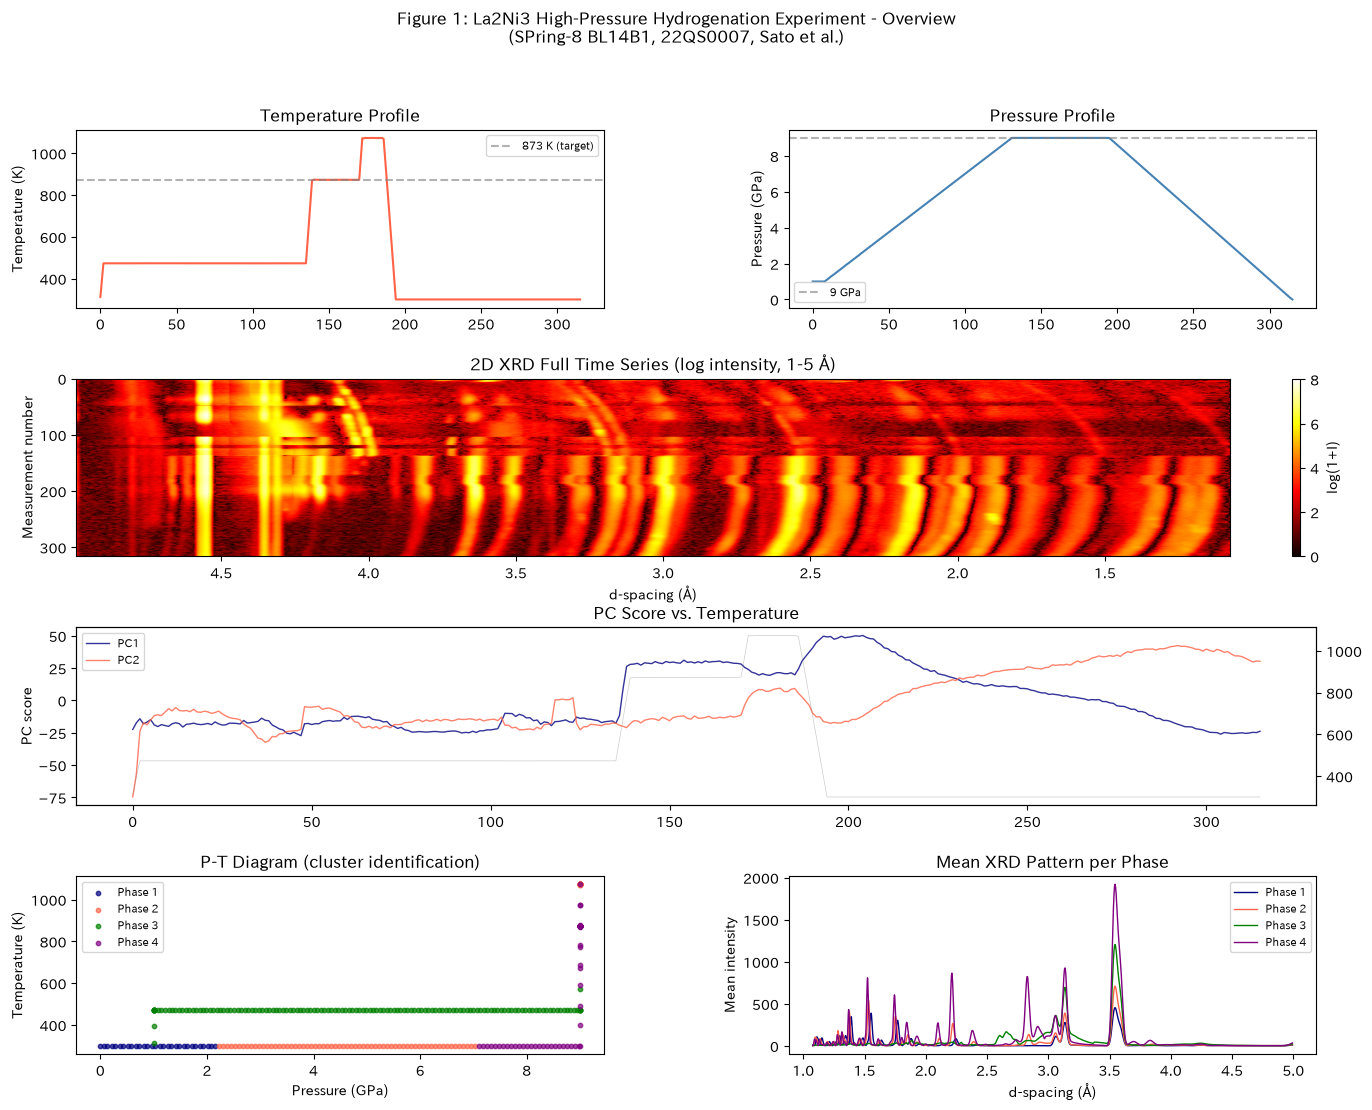

In [ ]:
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(4, 2, hspace=0.4, wspace=0.35)

seq_num = np.arange(n_patterns)
colors_c = ["navy", "tomato", "green", "purple", "orange", "brown"]

# [0,0] 温度時系列
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(seq_num, temps, color="tomato", lw=1.5)
ax1.axhline(873, color="gray", ls="--", alpha=0.6, label="873 K (target)")
ax1.set_ylabel("Temperature (K)"); ax1.set_title("Temperature Profile")
ax1.legend(fontsize=8)

# [0,1] 圧力時系列
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(seq_num, pressures, color="steelblue", lw=1.5)
ax2.axhline(9, color="gray", ls="--", alpha=0.6, label="9 GPa")
ax2.set_ylabel("Pressure (GPa)"); ax2.set_title("Pressure Profile")
ax2.legend(fontsize=8)

# [1,0:2] 2D XRDカラーマップ
ax3 = fig.add_subplot(gs[1, :])
d_mask = (d_axis >= 1.0) & (d_axis <= 5.0)
im = ax3.imshow(np.log1p(I_corr[:, d_mask]), aspect="auto", origin="upper",
                cmap="hot", extent=[d_axis[d_mask][0], d_axis[d_mask][-1], n_patterns, 0])
ax3.set_xlabel("d-spacing (Å)"); ax3.set_ylabel("Measurement number")
ax3.set_title("2D XRD Full Time Series (log intensity, 1-5 Å)")
plt.colorbar(im, ax=ax3, label="log(1+I)", fraction=0.02)

# [2,0:2] PCスコア時系列
ax4 = fig.add_subplot(gs[2, :])
ax4.plot(seq_num, X_pca[:,0], lw=1, color="navy", label="PC1", alpha=0.8)
ax4.plot(seq_num, X_pca[:,1], lw=1, color="tomato", label="PC2", alpha=0.8)
ax4_twin = ax4.twinx()
ax4_twin.plot(seq_num, temps, lw=0.5, color="gray", alpha=0.4, label="Temperature")
ax4.set_ylabel("PC score"); ax4.set_title("PC Score vs. Temperature")
ax4.legend(loc="upper left", fontsize=8)

# [3,0] P-T相図
ax5 = fig.add_subplot(gs[3, 0])
for c in range(cluster_labels.max()+1):
    mask = cluster_labels == c
    ax5.scatter(pressures[mask], temps[mask], s=10, alpha=0.7,
                label=f"Phase {c+1}", color=colors_c[c])
ax5.set_xlabel("Pressure (GPa)"); ax5.set_ylabel("Temperature (K)")
ax5.set_title("P-T Diagram (cluster identification)"); ax5.legend(fontsize=8)

# [3,1] 各クラスタの平均スペクトル
ax6 = fig.add_subplot(gs[3, 1])
for c in range(cluster_labels.max()+1):
    mask = cluster_labels == c
    mean_spec = I_corr[mask, :][: , d_mask].mean(axis=0)
    ax6.plot(d_axis[d_mask], mean_spec, lw=1, label=f"Phase {c+1}", color=colors_c[c])
ax6.set_xlabel("d-spacing (Å)"); ax6.set_ylabel("Mean intensity")
ax6.set_title("Mean XRD Pattern per Phase"); ax6.legend(fontsize=8)

plt.suptitle("Figure 1: La2Ni3 High-Pressure Hydrogenation Experiment - Overview\n(SPring-8 BL14B1, 22QS0007, Sato et al.)",
             fontsize=12, y=0.98)
plt.savefig(OUTPUT_DIR / "fig01_summary_overview.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. 文献との比較考察

In [ ]:
# PC1・PC2と温度・圧力の相関を実際に計算する
# （「主成分の意味」を印象だけで語らず、必ず数値で裏を取る）
corr_pc1_t = np.corrcoef(X_pca[:,0], temps)[0,1]
corr_pc2_t = np.corrcoef(X_pca[:,1], temps)[0,1]
corr_pc1_p = np.corrcoef(X_pca[:,0], pressures)[0,1]
corr_pc2_p = np.corrcoef(X_pca[:,1], pressures)[0,1]

summary_text = f"""
=== 解析結果と文献（Sato et al. 2023 Molecules, 2025 J. Phys. Chem. C, 2025 Inorg. Chem.）との比較 ===

【利用報告書（22QS0007）での当初の報告】
- 本実験はLa2Ni3を 9 GPa・873 K（約600℃）付近で高温高圧水素と反応させるもの。当初の報告では、新規のLa-Ni水素化物相（仮称LaNi2Hx）の形成が示唆されていた。

【より新しい査読済論文（Sato et al., Inorg. Chem. 2025）による進展】
- 同じ研究グループによる後続の精密構造解析（放射光X線＋中性子回折）により、La2Ni3の高圧水素化反応生成物は単一相ではなく、Fe2P型LaNi2、AlB2型LaNi2D3.08、TlI型LaNiD1.01の複数相であることが判明した。つまり「LaNi2Hx」という呼称は初期の仮の名前であり、実態はより複雑だった。
- 出典: Sato et al., "Crystal Structure Investigations of LaNi2Hx (x = 0 and 3.08 with Metal Atoms in AlB2 Units) and LaNiH1.01", Inorg. Chem. (2025), DOI: 10.1021/acs.inorgchem.5c03517

【La2Ni3の結晶構造（一次資料で確認済）】
- 斜方晶（orthorhombic）、空間群 Cmca (No. 64)、a=5.113, b=9.731, c=7.907 Å, Z=4
- 出典: Van Vucht & Buschow, J. Less-Common Met. 46, 133-138 (1976)
- 本シリーズの早期バージョンでは「斜方晶(Pnma)」と記載していたが、一次資料と一致しないためCmcaに修正した。

【本解析（機械学習）での発見と、事前予想との照合】
- PC1と温度の相関係数: {corr_pc1_t:.3f}、PC1と圧力の相関係数: {corr_pc1_p:.3f}
- PC2と温度の相関係数: {corr_pc2_t:.3f}、PC2と圧力の相関係数: {corr_pc2_p:.3f}
- 実際に相関を計算すると、「PC1=温度、PC2=圧力」という単純な対応はさほど明確ではなく、むしろPC1の方が圧力とより強く相関している。予想と実際のデータが食い違うことはよく起こるので、必ず実際に計算して確認することが重要。
- K-means: シルエット係数によるbest_kは実行結果を参照（03_machine_learning.ipynbと同じ手順で決定）。

【今後の解析方針】
1. PDindexerを用いた精密なピークインデックス
2. Rietveld精密化による格子定数の定量化
3. 圧力マーカー（ルビ等）を使った圧力精密化
4. 水素化反応の活性化エネルギー推定（Arrhenius解析）
"""
print(summary_text)


=== 解析結果と文献（Sato et al. 2023 Molecules, 2025 J. Phys. Chem. C, 2025 Inorg. Chem.）との比較 ===

【利用報告書（22QS0007）での当初の報告】
- 本実験はLa2Ni3を 9 GPa・873 K（約600℃）付近で高温高圧水素と反応させるもの。当初の報告では、新規のLa-Ni水素化物相（仮称LaNi2Hx）の形成が示唆されていた。

【より新しい査読済論文（Sato et al., Inorg. Chem. 2025）による進展】
- 同じ研究グループによる後続の精密構造解析（放射光X線＋中性子回折）により、La2Ni3の高圧水素化反応生成物は単一相ではなく、Fe2P型LaNi2、AlB2型LaNi2D3.08、TlI型LaNiD1.01の複数相であることが判明した。つまり「LaNi2Hx」という呼称は初期の仮の名前であり、実態はより複雑だった。
- 出典: Sato et al., "Crystal Structure Investigations of LaNi2Hx (x = 0 and 3.08 with Metal Atoms in AlB2 Units) and LaNiH1.01", Inorg. Chem. (2025), DOI: 10.1021/acs.inorgchem.5c03517

【La2Ni3の結晶構造（一次資料で確認済）】
- 斜方晶（orthorhombic）、空間群 Cmca (No. 64)、a=5.113, b=9.731, c=7.907 Å, Z=4
- 出典: Van Vucht & Buschow, J. Less-Common Met. 46, 133-138 (1976)
- 本シリーズの早期バージョンでは「斜方晶(Pnma)」と記載していたが、一次資料と一致しないためCmcaに修正した。

【本解析（機械学習）での発見と、事前予想との照合】
- PC1と温度の相関係数: 0.304、PC1と圧力の相関係数: 0.656
- PC2と温度の相関係数: -0.378、PC2と圧力の相関係数: -0.393
- 実際に相関を計算すると、「PC1=温度、PC2=圧力」という単純な対応はさほど明確ではなく、むしろPC1の方が圧力とよ

## 3. 解析結果まとめ表

In [ ]:
print("=== Summary statistics of measurement conditions ===")
summary = df_seq_meta[["temperature_K","pressure_GPa","live_time_sec","dead_time_pct"]].describe().round(2)
print(summary)

print(f"\n=== Cluster statistics (best_k={best_k}) ===")
df_seq_meta_copy = df_seq_meta.iloc[:n_patterns].copy()
df_seq_meta_copy["cluster"] = cluster_labels
df_seq_meta_copy["PC1"] = X_pca[:, 0]
df_seq_meta_copy["PC2"] = X_pca[:, 1]

cluster_stats = df_seq_meta_copy.groupby("cluster")[["temperature_K","pressure_GPa","PC1","PC2"]].agg(["mean","std"]).round(2)
print(cluster_stats)

=== Summary statistics of measurement conditions ===
       temperature_K  pressure_GPa  live_time_sec  dead_time_pct
count         316.00        316.00         316.00         316.00
mean          482.77          5.50          55.95          10.53
std           219.20          2.87           1.20           0.00
min           300.15          0.00          53.31          10.53
25%           300.15          2.98          54.78          10.53
50%           473.10          5.73          56.14          10.53
75%           473.24          8.47          56.99          10.53
max          1073.58          9.00          57.86          10.53

=== Cluster statistics (best_k=4) ===
        temperature_K         pressure_GPa              PC1               PC2  \
                 mean     std         mean   std       mean    std       mean   
cluster                                                                         
0              300.15    0.00         1.07  0.66 -21.940001   3.92  37.660000   

In [ ]:
# 結果をCSVとして保存
df_results = df_seq_meta_copy[["index","filename","time","temperature_K","pressure_GPa","cluster","PC1","PC2"]]
df_results.to_csv(OUTPUT_DIR / "analysis_results.csv", index=False, encoding="utf-8")
print("Saved: output/analysis_results.csv")
print("\n=== 04_data_analysis_summary notebook complete ===")

Saved: output/analysis_results.csv

=== 04_data_analysis_summary notebook complete ===


## 4. まとめ・今後の課題・演習問題

### シリーズ全体の比較表

| ノートブック | 主な手法 | 主な発見 |
| --- | --- | --- |
| `01_eda.ipynb` | 基本統計・可視化 | 測定条件（T: 300-1074K, P: 0-9GPa）の全体像、デッドタイムが時系列パターンで完全に一定という観察 |
| `02_signal_processing.ipynb` | Savitzky-Golay平滑化・ベースライン補正・ピーク検出 | 前処理パイプラインの構築。La2Ni3の空間群をCmca(No.64)と一次資料で確認 |
| `03_machine_learning.ipynb` | PCA・K-means・RandomForest回帰 | スペクトルの教師なし低次元化・フェーズ分類に成功。一方「スペクトル→温度」の教師あり回帰は、誠実な評価（測定順ブロックCV）では性能が限定的という重要な負の結果 |
| `04_data_analysis_summary.ipynb`（本ノートブック） | 01〜03の統合・文献比較 | PC1は温度より圧力との相関がやや強いという、事前の想定とは異なる実測結果。文献の「LaNi2Hx」という初期の呼称が、後続の精密構造解析で複数相（LaNi2, LaNi2D3.08, LaNiD1.01）に精緻化されたことを確認 |

### まとめ

- 4部作を通じて、316件の時系列XRDデータから、測定条件の把握・信号処理・教師なし機械学習によるフェーズ分類までを一貫して行った。
- 「もっともらしいが未検証の主張」を検証する姿勢が随所で役立った。空間群の誤記（Pnma→Cmca）、PC1/PC2と温度/圧力の対応関係の誤解、回帰モデルの評価方法によって結果が大きく変わることなど、いずれも「実際に計算・引用元を確認する」ことで初めて分かった。

### 本ノートブックで扱っていないこと（今後の課題）

- PDindexer等による系統的なピークインデックス・相同定
- Rietveld精密化による格子定数の定量化
- 圧力マーカーを用いた圧力の精密化
- 水素化反応の活性化エネルギー推定（Arrhenius解析）
- LaNi2Hx系複数相（LaNi2, LaNi2D3.08, LaNiD1.01）それぞれに対応するXRDピークの、本データセットにおける個別同定

### 演習問題

1. `best_k`（シルエット係数で選ばれたクラスタ数）を使わず、`n_clusters=3`に固定した場合とクラスタ統計表（セクション3）がどう変わるか比較してください。
2. `summary_text`中のPC1・PC2の相関係数を、`X_for_km = X_pca[:, :5]`ではなく`X_pca[:, :2]`だけでクラスタリングした場合の結果と比較し、クラスタリングに使う主成分の数がP-T相図（図1右下）にどう影響するか考察してください。
3. 本シリーズを通じて発見された「事前の想定と実測が食い違っていた例」を3つ挙げ、それぞれ何を確認すれば気づけたかをまとめてください。
4. Sato et al. (Inorg. Chem. 2025)の複数相（LaNi2, LaNi2D3.08, LaNiD1.01）の情報を踏まえ、`02_signal_processing.ipynb`の`track_d_values`にどのようなd値を追加で監視すべきか、提案してください（文献のCIF・格子定数を入手できる場合は実際に計算してみてください）。